In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv(r"D:\practise\datasets\loan.csv")
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [18]:
# dataset["Gender"] = dataset["Gender"].fillna("unknown")
# dataset["Married"] = dataset["Married"].fillna("unknown")
# dataset["Dependents"] = dataset["Dependents"].fillna("unknown")
# dataset["Self_Employed"] = dataset["Self_Employed"].fillna("unknown")
# dataset["Property_Area"] = dataset["Property_Area"].fillna("unknown")

# dataset.isnull().sum()
# loan amount use median, Loan_Amount_Term use mode, 

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Model_name: Random Forest Accuracy: 1.0 0.7479674796747967 precision: 0.7474747474747475 recall: 0.925 f1_score: 0.8268156424581006
Model_name: Decision Tree Accuracy: 0.8370672097759674 0.7479674796747967 precision: 0.7425742574257426 recall: 0.9375 f1_score: 0.8287292817679558
Model_name: Logistic Regression Accuracy: 0.8187372708757638 0.7886178861788617 precision: 0.7596153846153846 recall: 0.9875 f1_score: 0.8586956521739131
Model_name: SVM Accuracy: 0.8289205702647657 0.7886178861788617 precision: 0.7596153846153846 recall: 0.9875 f1_score: 0.8586956521739131
Model_name: KNN Accuracy: 0.845213849287169 0.7479674796747967 precision: 0.7474747474747475 recall: 0.925 f1_score: 0.8268156424581006
Model_name: Gradient Boosting Accuracy: 0.8228105906313645 0.7886178861788617 precision: 0.7596153846153846 recall: 0.9875 f1_score: 0.8586956521739131


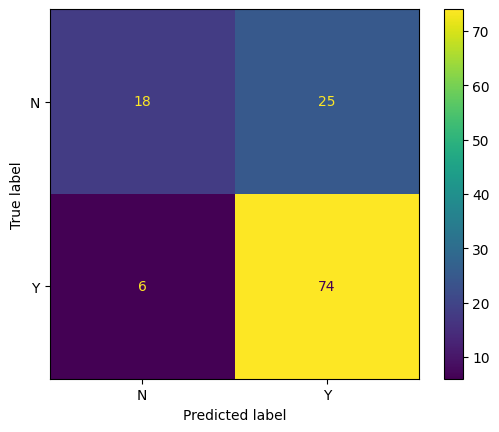

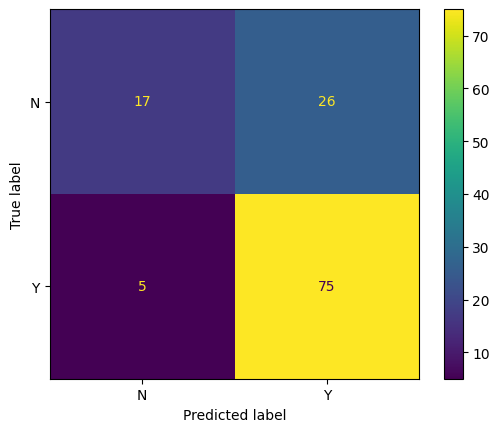

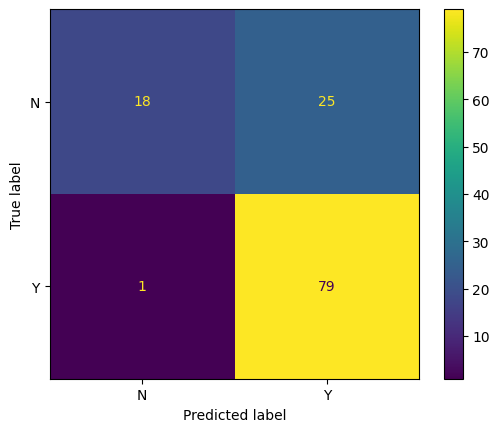

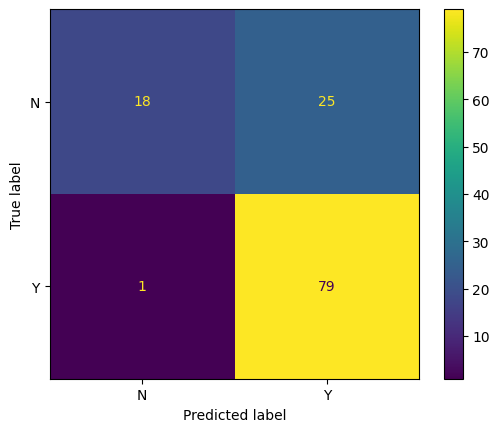

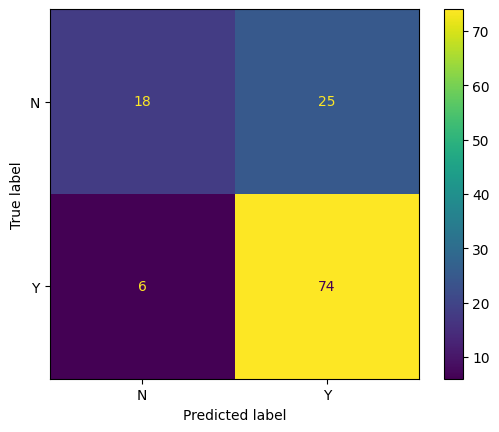

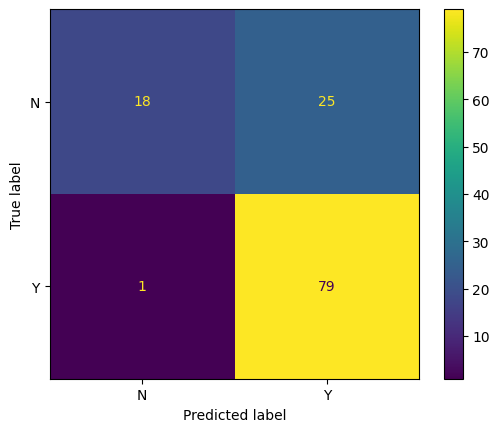

In [5]:
from sklearn.metrics import confusion_matrix


numeric_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Credit_History"]
categorical_features = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]

income_amount_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

term_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

categorical_data = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", income_amount_pipeline, numeric_features),
    ("term", term_pipeline, ["Loan_Amount_Term"]),
    ("categorical", categorical_data, categorical_features)
])

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10)
    }

for name, model in models.items():
    model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", model)
    ])
    model_pipeline.fit(x_train, y_train)
    y_pred = model_pipeline.predict(x_test)
    print("Model_name:", name ,"Accuracy:", model_pipeline.score(x_train, y_train), model_pipeline.score(x_test, y_test), "precision:", precision_score(y_test, y_pred, pos_label='Y'), "recall:", recall_score(y_test, y_pred, pos_label='Y'), "f1_score:", f1_score(y_test, y_pred, pos_label='Y'))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)








In [6]:
import joblib
final_model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
    ])

final_model_pipeline.fit(x_train, y_train)
y_pred = final_model_pipeline.predict(x_test)
print("Model_name:", "Logistic Regression" ,"Accuracy:", final_model_pipeline.score(x_train, y_train), final_model_pipeline.score(x_test, y_test), "precision:", precision_score(y_test, y_pred, pos_label='Y'), "recall:", recall_score(y_test, y_pred, pos_label='Y'), "f1_score:", f1_score(y_test, y_pred, pos_label='Y'))

joblib.dump(final_model_pipeline, "loan_prediction_model.joblib")

Model_name: Logistic Regression Accuracy: 0.8187372708757638 0.7886178861788617 precision: 0.7596153846153846 recall: 0.9875 f1_score: 0.8586956521739131


['loan_prediction_model.joblib']

In [ ]:
{
  "Loan_ID": "LM1234",
  "Gender": "Male",
  "Married": "Yes",
  "Dependents": "1",
  "Education": "Graduate",
  "Self_Employed": "No",
  "ApplicantIncome": 4583,
  "CoapplicantIncome": 1508.0,
  "LoanAmount": 128.0,
  "Loan_Amount_Term": 360.0,
  "Credit_History": 1.0,
  "Property_Area": "Rural"
}
